# Introduction to Machine Learning: Unsupervised Learning

**Instructor:** Daniel Acuna, Ph.D.
**Position:** Associate Professor of Computer Science
**Institution:** University of Colorado Boulder

---

Lab 5: Matrix Completion and Recommender Systems

---

In this lab, you will explore **Matrix Completion**, a powerful technique
for filling in missing values in matrices using low-rank approximation.
This approach is the foundation of many **recommender systems** like
Netflix and Amazon product recommendations.

You will work with a synthetic **user-movie rating matrix** that mimics
real recommender system data, with most entries missing. You will:

- Understand the structure of sparse rating matrices
- Implement mean imputation as a baseline
- Use SVD for low-rank matrix approximation
- Build an iterative matrix completion algorithm
- Evaluate imputation quality using held-out validation
- Apply your methods to predict user preferences

These skills are essential for building recommendation engines,
handling missing data in machine learning pipelines, and understanding
the connection between SVD/PCA and matrix factorization.

## Setup (do not edit)

In [1]:
import pathlib
from typing import Tuple, Dict, List, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.linalg import svd

RANDOM_STATE: int = 42
np.random.seed(RANDOM_STATE)

_DATA_PATH = pathlib.Path("ratings.csv")
if not _DATA_PATH.exists():
    raise FileNotFoundError(
        "ratings.csv is missing from the lab directory. Please run the download "
        "script (w5_download_datasets.py) or ask the TA for assistance."
    )

## 1. Load and Explore the Ratings Dataset *(10 points)*

Load the ratings data from `ratings.csv`. This file contains user-movie
ratings in **long format** with columns: `user_id`, `movie_id`, `rating`.

Each row represents one rating that a user gave to a movie. Most user-movie
combinations are missing (not rated), which is typical of recommender
system data.

Store the following in the required variables:
- **`q1_df`**: The loaded DataFrame
- **`q1_n_ratings`**: Total number of ratings (rows in the DataFrame)
- **`q1_n_users`**: Number of unique users
- **`q1_n_movies`**: Number of unique movies
- **`q1_rating_range`**: A tuple containing (min_rating, max_rating)

In [3]:
# Grade Cell: Question 1
#
# Task: Load the ratings dataset and explore its structure
#
# Instructions:
# 1. Read the CSV file using pd.read_csv()
# 2. Count total ratings, unique users, and unique movies
# 3. Find the minimum and maximum rating values

# laod data from csv into dataframe
q1_df = pd.read_csv(_DATA_PATH)

# total number of rows = total number of ratings
q1_n_ratings = len(q1_df)

#count of unique user & movie ids
q1_n_users = q1_df['user_id'].nunique()
q1_n_movies = q1_df['movie_id'].nunique()

#min/max of the rating column
q1_rating_range = (q1_df['rating'].min(), q1_df['rating'].max())

In [4]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 1
assert isinstance(
    q1_df, pd.DataFrame
), "q1_df must be a pandas DataFrame. Use pd.read_csv() to load the data."
assert set(q1_df.columns) == {"user_id", "movie_id", "rating"}, (
    "DataFrame should have columns: user_id, movie_id, rating. "
    "Check that you loaded the correct file."
)
assert isinstance(q1_n_ratings, int), "q1_n_ratings must be an integer."
assert q1_n_ratings > 0, "There should be at least some ratings."
assert isinstance(q1_n_users, int), "q1_n_users must be an integer."
assert isinstance(q1_n_movies, int), "q1_n_movies must be an integer."
assert isinstance(q1_rating_range, tuple), "q1_rating_range must be a tuple."
assert len(q1_rating_range) == 2, "q1_rating_range should be (min, max)."
assert q1_rating_range[0] <= q1_rating_range[1], "Min should be <= max."
print(f"Total ratings: {q1_n_ratings}")
print(f"Unique users: {q1_n_users}")
print(f"Unique movies: {q1_n_movies}")
print(f"Rating range: {q1_rating_range}")

Total ratings: 1214
Unique users: 100
Unique movies: 50
Rating range: (1.0, 5.0)


## 2. Create Rating Matrix and Compute Sparsity *(10 points)*

Convert the long-format ratings to a **rating matrix** where:
- Rows represent users (user_id)
- Columns represent movies (movie_id)
- Each cell contains the rating, or NaN if the user hasn't rated that movie

Then compute the **sparsity** of the matrix, which is the fraction of
entries that are missing.

Store the results as:
- **`q2_rating_matrix`**: A numpy array of shape (n_users, n_movies) with NaN for missing
- **`q2_n_missing`**: Total number of missing entries (NaN values)
- **`q2_sparsity`**: Fraction of entries that are missing (float, rounded to 3 decimals)

In [7]:
# Grade Cell: Question 2
#
# Task: Create the rating matrix and compute sparsity
#
# Instructions:
# 1. Initialize a matrix of NaN values with shape (n_users, n_movies)
# 2. Fill in the observed ratings from the DataFrame
# 3. Count NaN values and compute sparsity as n_missing / total_entries

# Get the unique ids so we can map them to matrix positions
unique_users = np.sort(q1_df['user_id'].unique())
unique_movies = np.sort(q1_df['movie_id'].unique())

user_to_idx = {u: i for i, u in enumerate(unique_users)}
movie_to_idx = {m: i for i, m in enumerate(unique_movies)}

# start will all nan matrix (nan = missing rating)
q2_rating_matrix = np.full((q1_n_users, q1_n_movies), np.nan)

# Convert each rows user/movie ids into matrix (row/col) positions
user_idx = q1_df['user_id'].map(user_to_idx).values
movie_idx = q1_df['movie_id'].map(movie_to_idx).values
ratings = q1_df['rating'].values

# fill in observed ratings
q2_rating_matrix[user_idx, movie_idx] = ratings

# count and compute the 
q2_n_missing = int(np.isnan(q2_rating_matrix).sum())
q2_sparsity = round(q2_n_missing / q2_rating_matrix.size, 3)





In [8]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 2
assert isinstance(
    q2_rating_matrix, np.ndarray
), "q2_rating_matrix must be a numpy array."
assert q2_rating_matrix.shape == (q1_n_users, q1_n_movies), (
    f"Matrix shape should be ({q1_n_users}, {q1_n_movies}). "
    "Rows are users, columns are movies."
)
assert np.isnan(q2_rating_matrix).any(), (
    "Matrix should contain NaN values for missing ratings. "
    "Initialize with np.full(..., np.nan)."
)
assert isinstance(q2_n_missing, int), "q2_n_missing must be an integer."
assert q2_n_missing > 0, "There should be missing entries."
assert isinstance(q2_sparsity, float), "q2_sparsity must be a float."
assert (
    0 < q2_sparsity < 1
), "Sparsity should be between 0 and 1 (fraction of missing entries)."
# The sum of observed ratings should match our original count
n_observed = (~np.isnan(q2_rating_matrix)).sum()
assert n_observed == q1_n_ratings, (
    "Number of observed entries should match q1_n_ratings. "
    "Check your matrix filling logic."
)
print(f"Rating matrix shape: {q2_rating_matrix.shape}")
print(f"Missing entries: {q2_n_missing}")
print(f"Sparsity: {q2_sparsity:.1%}")

Rating matrix shape: (100, 50)
Missing entries: 3786
Sparsity: 75.7%


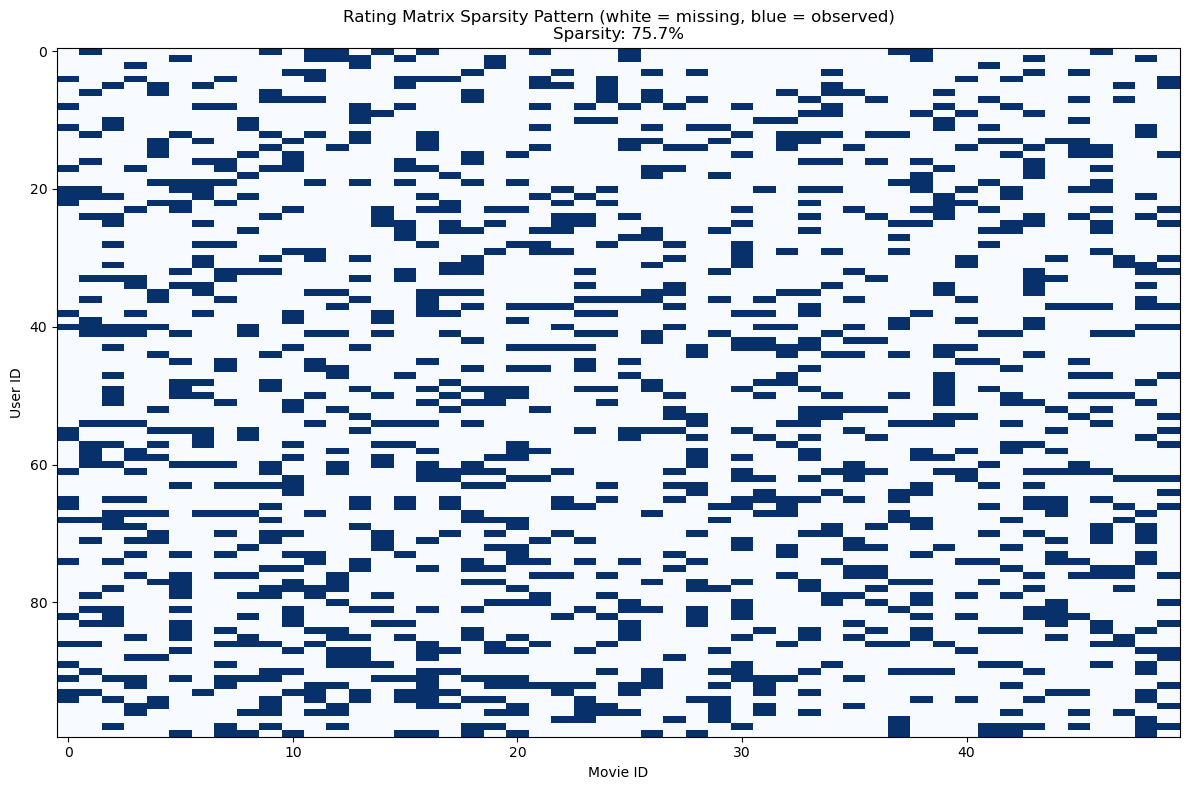

In [9]:
# Visualize the sparsity pattern
fig, ax = plt.subplots(figsize=(12, 8))
mask = ~np.isnan(q2_rating_matrix)
ax.imshow(mask, aspect="auto", cmap="Blues", interpolation="nearest")
ax.set_xlabel("Movie ID")
ax.set_ylabel("User ID")
ax.set_title(
    f"Rating Matrix Sparsity Pattern (white = missing, blue = observed)\nSparsity: {q2_sparsity:.1%}"
)
plt.tight_layout()
plt.show()

## 3. Center the Rating Matrix *(10 points)*

Before applying matrix completion, we need to **center** the data by
subtracting the mean rating for each movie (column mean). This removes
the baseline popularity of movies and focuses on deviations.

Important: When computing column means, only use **observed** (non-NaN)
values. Then subtract these means from the observed values.

Store the results as:
- **`q3_movie_means`**: A numpy array of length n_movies with each movie's mean rating
- **`q3_centered_matrix`**: The centered rating matrix (still has NaN for missing)
- **`q3_centered_mean`**: The overall mean of the centered observed values (should be ~0)

In [10]:
# Grade Cell: Question 3
#
# Task: Center the rating matrix by movie means
#
# Instructions:
# 1. Compute the mean of each column, ignoring NaN values (use np.nanmean)
# 2. Subtract these means from the observed values
# 3. Verify that the centered matrix has mean ~0

# column-wise mean rating per movie, ignoring missing vals
q3_movie_means = np.nanmean(q2_rating_matrix, axis = 0)

# subtract each movie mean from its column, following the (n_users, n_movies) - (n_movies) shape
q3_centered_matrix = q2_rating_matrix - q3_movie_means

q3_centered_mean = float(np.nanmean(q3_centered_matrix))

In [11]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 3
assert isinstance(q3_movie_means, np.ndarray), "q3_movie_means must be a numpy array."
assert q3_movie_means.shape == (
    q1_n_movies,
), f"q3_movie_means should have length {q1_n_movies} (one mean per movie)."
assert not np.isnan(
    q3_movie_means
).any(), (
    "Movie means should not contain NaN. Each movie should have at least one rating."
)
assert isinstance(
    q3_centered_matrix, np.ndarray
), "q3_centered_matrix must be a numpy array."
assert (
    q3_centered_matrix.shape == q2_rating_matrix.shape
), "Centered matrix should have the same shape as the original."
# Should still have NaN in the same places
assert (
    np.isnan(q3_centered_matrix).sum() == q2_n_missing
), "Centering should not change which entries are missing."
assert isinstance(q3_centered_mean, float), "q3_centered_mean must be a float."
assert abs(q3_centered_mean) < 0.1, (
    f"Centered mean is {q3_centered_mean}, expected ~0. "
    "Did you subtract movie means from all observed values?"
)
print(f"Movie means (first 5): {q3_movie_means[:5].round(2)}")
print(f"Centered mean: {q3_centered_mean}")

Movie means (first 5): [2.53 2.06 2.26 2.57 2.22]
Centered mean: 8.267229112529996e-17


## 4. Mean Imputation Baseline *(10 points)*

The simplest imputation strategy is **mean imputation**: replace each
missing value with the mean of its column (movie mean).

Since we've already centered the data, mean imputation simply replaces
NaN values with 0 (the centered mean).

Store the results as:
- **`q4_mean_imputed`**: The centered matrix with NaN replaced by 0
- **`q4_has_nan`**: Boolean indicating if any NaN values remain (should be False)
- **`q4_imputed_range`**: Tuple of (min, max) values in the imputed matrix

In [13]:
# Grade Cell: Question 4
#
# Task: Perform mean imputation on the centered matrix
#
# Instructions:
# 1. Replace all NaN values with 0 (since data is centered)
# 2. Verify no NaN values remain
# 3. Compute the range of values in the imputed matrix

# Since the matrix is centered(mean subtracted), 0 represents avg rating
#    so replacing missing vals with 0 is reasonable
q4_mean_imputed = np.nan_to_num(q3_centered_matrix, nan = 0.0)

# confrim no missing values remain
q4_has_nan = bool(np.isnan(q4_mean_imputed).any())

# min/max across the matrix
q4_imputed_range = (float(q4_mean_imputed.min()), float(q4_mean_imputed.max()))

In [14]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 4
assert isinstance(q4_mean_imputed, np.ndarray), "q4_mean_imputed must be a numpy array."
assert (
    q4_mean_imputed.shape == q3_centered_matrix.shape
), "Imputed matrix should have the same shape."
assert isinstance(q4_has_nan, bool), "q4_has_nan must be a boolean."
assert q4_has_nan is False, (
    "After imputation, there should be no NaN values. "
    "Use np.nan_to_num() or np.where() to replace NaN."
)
assert isinstance(q4_imputed_range, tuple), "q4_imputed_range must be a tuple."
assert len(q4_imputed_range) == 2, "q4_imputed_range should be (min, max)."
# The imputed values (which were 0) should bring the mean closer to 0
imputed_mean = q4_mean_imputed.mean()
assert abs(imputed_mean) < 0.5, "Mean of imputed matrix should be close to 0."
print(f"Imputed matrix shape: {q4_mean_imputed.shape}")
print(f"Contains NaN: {q4_has_nan}")
print(f"Value range: {q4_imputed_range}")

Imputed matrix shape: (100, 50)
Contains NaN: False
Value range: (-1.8760000000000001, 1.9608695652173913)


## 5. SVD-based Matrix Reconstruction *(10 points)*

Now let's use **Singular Value Decomposition (SVD)** to create a low-rank
approximation of the imputed matrix. The truncated SVD gives us:

$$\mathbf{X} \approx \mathbf{U}_M \boldsymbol{\Sigma}_M \mathbf{V}_M^T$$

where we keep only the top $M$ singular values.

Implement a function that computes a rank-$M$ approximation of a matrix
using SVD, then use it to reconstruct the mean-imputed matrix.

Store the results as:
- **`q5_reconstruct_matrix`**: A function that takes (matrix, rank) and returns the reconstruction
- **`q5_reconstructed`**: The rank-5 reconstruction of q4_mean_imputed
- **`q5_reconstruction_error`**: RMSE between original and reconstructed (rounded to 4 decimals)

In [15]:
# Grade Cell: Question 5
#
# Task: Implement SVD-based matrix reconstruction
#
# Instructions:
# 1. Use np.linalg.svd to decompose the matrix
# 2. Keep only the top M singular values and corresponding vectors
# 3. Reconstruct using U_M @ diag(S_M) @ V_M^T
# 4. Compute RMSE as sqrt(mean((original - reconstructed)^2))

def q5_reconstruct_matrix(matrix: np.ndarray, rank: int) -> np.ndarray:
    ''' Reconsturct the matrix using rank-'rank' truncated SVD approximation'''
    # full_matrices = False 
    #   this gives the thin svd which is neough since we only ever keep the 'rank' components
    U, S, Vt = np.linalg.svd(matrix, full_matrices = False)
    
    # keep only the top 'rank' 
    U_M = U[:, :rank]
    S_M = S[:rank]
    Vt_M = Vt[:rank, :]
    
    # low rank reconstruction
    reconstruct = U_M @ np.diag(S_M) @ Vt_M
    return reconstruct

# Apply it to the mean-imputed matrix with: rank = 5
q5_reconstructed = q5_reconstruct_matrix(q4_mean_imputed, rank = 5)

# RMSE between the original (imputed) matrix and rank 5 reconstruction
q5_reconstruction_error = round(
                    float(np.sqrt(np.mean((q4_mean_imputed - q5_reconstructed) ** 2))), 4)

In [16]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 5
assert callable(
    q5_reconstruct_matrix
), "q5_reconstruct_matrix should be a callable function."
# Test the function with a simple matrix
test_matrix = np.array([[1, 2], [3, 4], [5, 6]], dtype=float)
test_result = q5_reconstruct_matrix(test_matrix, rank=1)
assert (
    test_result.shape == test_matrix.shape
), "Function should return a matrix of the same shape."
assert isinstance(
    q5_reconstructed, np.ndarray
), "q5_reconstructed must be a numpy array."
assert (
    q5_reconstructed.shape == q4_mean_imputed.shape
), "Reconstructed matrix should have the same shape as input."
assert not np.isnan(
    q5_reconstructed
).any(), "Reconstructed matrix should not contain NaN."
assert isinstance(
    q5_reconstruction_error, float
), "q5_reconstruction_error must be a float."
assert q5_reconstruction_error >= 0, "RMSE cannot be negative."
assert q5_reconstruction_error < 1, (
    "Reconstruction error seems too large. "
    "A rank-5 approximation should capture most of the variance."
)
print(f"Reconstructed matrix shape: {q5_reconstructed.shape}")
print(f"Reconstruction RMSE: {q5_reconstruction_error}")

Reconstructed matrix shape: (100, 50)
Reconstruction RMSE: 0.197


## 6. Iterative Matrix Completion Algorithm *(15 points)*

Mean imputation ignores the correlation structure in the data. A better
approach is the **iterative matrix completion algorithm**:

1. Initialize: Fill missing values with column means (done in Q4)
2. Repeat until convergence:
   - Compute rank-$M$ SVD of the current filled matrix
   - Update missing entries with values from the low-rank reconstruction
   - Keep observed entries unchanged
3. Return the completed matrix

This algorithm iteratively refines the imputed values using the low-rank
structure discovered by SVD.

Store the results as:
- **`q6_complete_matrix`**: A function implementing the iterative algorithm
- **`q6_completed`**: The completed matrix using rank=5 and max_iter=20
- **`q6_final_error`**: Final reconstruction error (RMSE on observed entries)

In [19]:
# Grade Cell: Question 6
#
# Task: Implement the iterative matrix completion algorithm
#
# Instructions:
# 1. Start with mean-imputed matrix
# 2. Create a mask for observed entries (not NaN in original)
# 3. Iterate: SVD reconstruct, update only missing entries
# 4. Track convergence by monitoring change in imputed values


def q6_complete_matrix(matrix: np.ndarray, mask: np.ndarray, rank: int,
                      max_iter: int = 20, tol: float = 1e-4):
    '''Iterativly complete matrix using rank='rank' SVD consturction.
    Observed entries where the mask is True, are always reset to their known
    values after each reconstruction, only the missing ones get updated by SVD estimate
    '''
    completed = matrix.copy()
    errors = [] # RMSE of change in the full matrix between the iterations
    
    for _ in range(max_iter):
        # get a low rank estimate of matrix
        reconstructed = q5_reconstruct_matrix(completed, rank)
        
        #keep observed entries, only take reconstruction vals for the missing
        new_completed = np.where(mask, matrix, reconstructed)
        
        #track how much the matrix changed this round
        change = float(np.sqrt(np.mean((new_completed - completed) ** 2 )))
        errors.append(change)
        
        completed = new_completed
        if change < tol:
            break
        
    return completed, errors

# The mask of entries that were actually observed in the origin data
q6_mask = ~np.isnan(q3_centered_matrix)


q6_completed, q6_errors = q6_complete_matrix(q4_mean_imputed, q6_mask, rank = 5, max_iter = 20)

#final RMSE between the completed matrix and the true observes vals
#   this should be small or close to zero 
q6_final_error = float(
            np.sqrt(np.mean((q6_completed[q6_mask] - q3_centered_matrix[q6_mask]) ** 2 )))

In [20]:
# If all tests pass (there might be hidden tests), you will earn 15 points
# Test Cell: Question 6
assert callable(q6_complete_matrix), "q6_complete_matrix should be a callable function."
assert isinstance(q6_completed, np.ndarray), "q6_completed must be a numpy array."
assert (
    q6_completed.shape == q3_centered_matrix.shape
), "Completed matrix should have the same shape as input."
assert not np.isnan(
    q6_completed
).any(), "Completed matrix should not contain NaN values."
# Check that observed values are preserved
mask = ~np.isnan(q3_centered_matrix)
observed_diff = np.abs(q6_completed[mask] - q3_centered_matrix[mask])
assert observed_diff.max() < 0.01, (
    "Observed values should be preserved (not changed during completion). "
    "Make sure you only update missing entries."
)
assert isinstance(q6_final_error, float), "q6_final_error must be a float."
assert q6_final_error >= 0, "RMSE cannot be negative."
print(f"Completed matrix shape: {q6_completed.shape}")
print(f"Number of iterations: {len(q6_errors)}")
print(f"Final RMSE on observed: {q6_final_error}")

Completed matrix shape: (100, 50)
Number of iterations: 20
Final RMSE on observed: 0.0


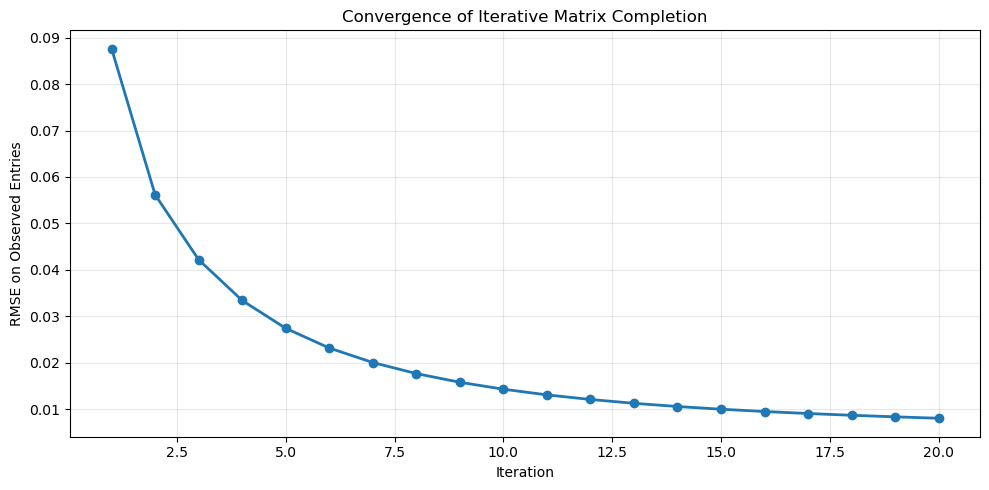

In [21]:
# Visualize convergence
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(q6_errors) + 1), q6_errors, "o-", linewidth=2, markersize=6)
ax.set_xlabel("Iteration")
ax.set_ylabel("RMSE on Observed Entries")
ax.set_title("Convergence of Iterative Matrix Completion")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Select Optimal Rank via Validation *(10 points)*

How do we choose the rank $M$ for matrix completion? We use **validation
by masking**: hide some observed entries, run completion, and measure
how well we recover them.

Implement a validation procedure:
1. Randomly mask 20% of observed entries (pretend they're missing)
2. Run matrix completion for different ranks M = 1, 2, 3, 5, 10
3. Measure recovery error on the masked entries
4. Select the rank with lowest validation error

Store the results as:
- **`q7_validation_errors`**: A dictionary mapping rank to validation RMSE
- **`q7_best_rank`**: The rank with lowest validation error
- **`q7_best_error`**: The lowest validation error

In [29]:
# Grade Cell: Question 7
#
# Task: Select optimal rank using validation by masking
#
# Instructions:
# 1. Create a validation mask: randomly hide 20% of observed entries
# 2. For each candidate rank, run completion and measure recovery on masked entries
# 3. Find the rank with lowest validation error

# Positions that were actually observed in the origin data
observed_mask = ~np.isnan(q3_centered_matrix)
observed_positions = np.argwhere(observed_mask)

# Randomly select 20% of observed positions to hold out for validation
n_val = int(0.2 * len(observed_positions))
val_choice = np.random.choice(len(observed_positions), size = n_val, replace = False)
val_positions = observed_positions[val_choice]

# bool mask marking the 'held' validation entries
val_mask = np.zeros_like(observed_mask)
val_mask[val_positions[:, 0], val_positions[:, 1]] = True

# training mask is the observed entries minus the 'held' ones
train_mask = observed_mask & ~val_mask

# Now we build a training matrix:
#  Real values at train positions, nan everwhere else
train_matrix = np.where(train_mask, q3_centered_matrix, np.nan)
train_imputed = np.nan_to_num(train_matrix, nan = 0.0)

candidate_ranks = [1, 2, 3, 5, 10]
q7_validation_errors = {}

for rank in candidate_ranks:
    #complete the matrix using only training entries
    completed, _ = q6_complete_matrix(train_imputed, train_mask, rank = rank, max_iter = 20)
    
    # compare recovered vals at the 'held' validation positions against their real values
    true_vals = q3_centered_matrix[val_mask]
    pred_vals = completed[val_mask]
    rmse = float(np.sqrt(np.mean((pred_vals - true_vals) ** 2)))
    
    q7_validation_errors[rank] = rmse

#rank with the lowest validation RMSE
q7_best_rank = min(q7_validation_errors, key = q7_validation_errors.get)
q7_best_error = q7_validation_errors[q7_best_rank]

In [30]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 7
assert isinstance(
    q7_validation_errors, dict
), "q7_validation_errors must be a dictionary."
assert set(q7_validation_errors.keys()) == {
    1,
    2,
    3,
    5,
    10,
}, "Should test ranks [1, 2, 3, 5, 10]."
for rank, error in q7_validation_errors.items():
    assert isinstance(error, float), f"Error for rank {rank} must be a float."
    assert error > 0, f"Error for rank {rank} should be positive."
assert isinstance(q7_best_rank, int), "q7_best_rank must be an integer."
assert (
    q7_best_rank in candidate_ranks
), "q7_best_rank should be one of the tested ranks."
assert isinstance(q7_best_error, float), "q7_best_error must be a float."
assert (
    q7_best_error == q7_validation_errors[q7_best_rank]
), "q7_best_error should match the error for q7_best_rank."
print("Validation errors by rank:")
for rank in sorted(q7_validation_errors.keys()):
    marker = " <-- best" if rank == q7_best_rank else ""
    print(f"  Rank {rank}: {q7_validation_errors[rank]:.4f}{marker}")
print(f"\nBest rank: {q7_best_rank} with error: {q7_best_error:.4f}")

Validation errors by rank:
  Rank 1: 0.4208 <-- best
  Rank 2: 0.4555
  Rank 3: 0.5000
  Rank 5: 0.4836
  Rank 10: 0.5108

Best rank: 1 with error: 0.4208


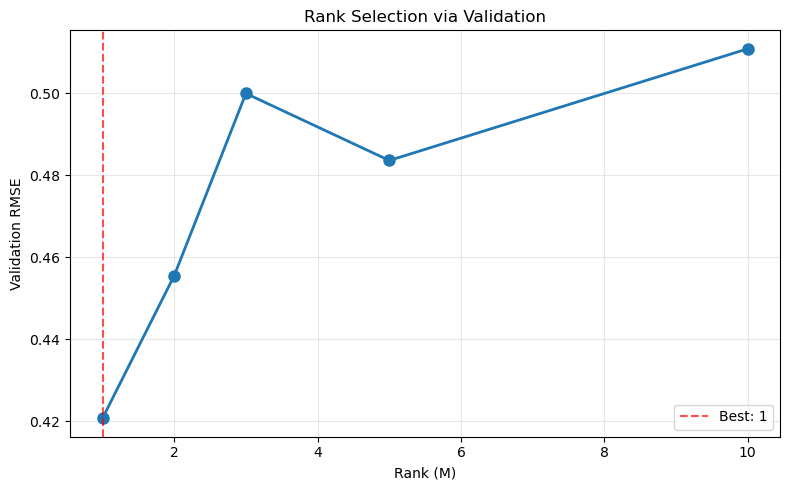

In [31]:
# Visualize validation errors by rank
fig, ax = plt.subplots(figsize=(8, 5))
ranks = sorted(q7_validation_errors.keys())
errors = [q7_validation_errors[r] for r in ranks]
ax.plot(ranks, errors, "o-", linewidth=2, markersize=8)
ax.axvline(
    q7_best_rank, color="red", linestyle="--", alpha=0.7, label=f"Best: {q7_best_rank}"
)
ax.set_xlabel("Rank (M)")
ax.set_ylabel("Validation RMSE")
ax.set_title("Rank Selection via Validation")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Evaluate Imputation Quality *(10 points)*

Now let's evaluate how well our matrix completion recovers the missing
values. We have access to the **ground truth** ratings (before masking)
stored in `ratings_ground_truth.csv`.

Compare the imputed values against the true values for entries that were
originally missing.

Store the results as:
- **`q8_ground_truth`**: The ground truth rating matrix (loaded from CSV)
- **`q8_imputed_missing`**: Array of imputed values for originally missing entries
- **`q8_true_missing`**: Array of true values for those same entries
- **`q8_correlation`**: Pearson correlation between imputed and true (rounded to 3 decimals)
- **`q8_rmse`**: RMSE between imputed and true (rounded to 3 decimals)

In [40]:
# Grade Cell: Question 8
#
# Task: Evaluate imputation quality against ground truth
#
# Instructions:
# 1. Load the ground truth matrix
# 2. Center it using the same movie means from Q3
# 3. Extract imputed and true values for originally missing entries
# 4. Compute correlation and RMSE

# Load ratings_ground_truth.csv file
_GROUND_TRUTH_PATH = pathlib.Path("ratings_ground_truth.csv")


q8_ground_truth = pd.read_csv(_GROUND_TRUTH_PATH).values

#gt_user_idx = gt_df['user_id'].map(user_to_idx).values
#gt_movie_idx = gt_df['movie_id'].map(movie_to_idx).values
#q8_ground_truth[gt_user_idx, gt_movie_idx] = gt_df['rating'].values

#Center it using the same per-movie means (same as question3)
q8_centered_truth = q8_ground_truth - q3_movie_means

# positions that were missing in the origin
missing_mask = np.isnan(q3_centered_matrix)

q8_imputed_missing = q6_completed[missing_mask]
q8_true_missing = q8_centered_truth[missing_mask]

q8_correlation = round(float(np.corrcoef(q8_imputed_missing, q8_true_missing)[0, 1]), 3)
q8_rmse = round(float(np.sqrt(np.mean((q8_imputed_missing - q8_true_missing) ** 2))), 3)


In [41]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 8
assert isinstance(q8_ground_truth, np.ndarray), "q8_ground_truth must be a numpy array."
assert (
    q8_ground_truth.shape == q2_rating_matrix.shape
), "Ground truth should have the same shape as the rating matrix."
assert isinstance(
    q8_imputed_missing, np.ndarray
), "q8_imputed_missing must be a numpy array."
assert isinstance(q8_true_missing, np.ndarray), "q8_true_missing must be a numpy array."
assert len(q8_imputed_missing) == len(
    q8_true_missing
), "Imputed and true arrays should have the same length."
assert (
    len(q8_imputed_missing) == q2_n_missing
), "Should have one imputed value per missing entry."
assert isinstance(q8_correlation, float), "q8_correlation must be a float."
assert -1 <= q8_correlation <= 1, "Correlation must be between -1 and 1."
assert isinstance(q8_rmse, float), "q8_rmse must be a float."
assert q8_rmse >= 0, "RMSE cannot be negative."
print(f"Number of missing entries evaluated: {len(q8_imputed_missing)}")
print(f"Correlation (imputed vs true): {q8_correlation}")
print(f"RMSE (imputed vs true): {q8_rmse}")

Number of missing entries evaluated: 3786
Correlation (imputed vs true): 0.455
RMSE (imputed vs true): 0.495


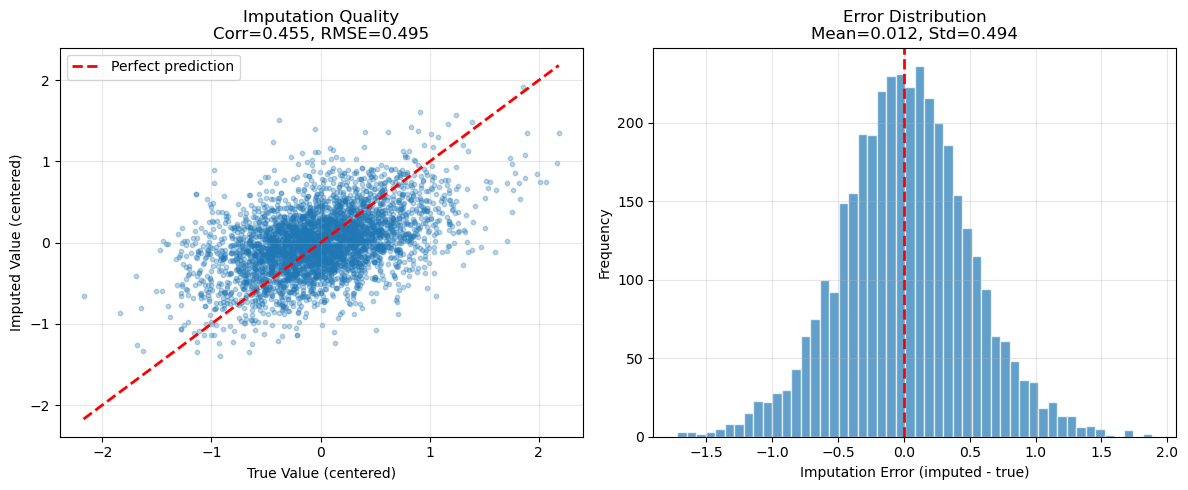

In [42]:
# Visualize imputed vs true values
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Scatter plot
ax1.scatter(q8_true_missing, q8_imputed_missing, alpha=0.3, s=10)
lims = [
    min(q8_true_missing.min(), q8_imputed_missing.min()),
    max(q8_true_missing.max(), q8_imputed_missing.max()),
]
ax1.plot(lims, lims, "r--", linewidth=2, label="Perfect prediction")
ax1.set_xlabel("True Value (centered)")
ax1.set_ylabel("Imputed Value (centered)")
ax1.set_title(f"Imputation Quality\nCorr={q8_correlation}, RMSE={q8_rmse}")
ax1.legend()
ax1.grid(alpha=0.3)

# Error distribution
errors = q8_imputed_missing - q8_true_missing
ax2.hist(errors, bins=50, edgecolor="white", alpha=0.7)
ax2.axvline(0, color="red", linestyle="--", linewidth=2)
ax2.set_xlabel("Imputation Error (imputed - true)")
ax2.set_ylabel("Frequency")
ax2.set_title(f"Error Distribution\nMean={errors.mean():.3f}, Std={errors.std():.3f}")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Recommender System: Predict User Ratings *(10 points)*

Now let's use our completed matrix as a **recommender system**. Given a
user and a movie they haven't rated, we can predict their rating.

Implement a function that:
1. Takes a user ID and movie ID
2. Returns the predicted rating (un-centered, on the original 1-5 scale)

Then use it to generate top-5 movie recommendations for a specific user.

Store the results as:
- **`q9_predict_rating`**: A function that predicts ratings
- **`q9_user_0_predictions`**: Dictionary of {movie_id: predicted_rating} for user 0's unrated movies
- **`q9_top_5_movies`**: List of top 5 movie IDs recommended for user 0

In [51]:
# Grade Cell: Question 9
#
# Task: Build a recommender system using the completed matrix
#
# Instructions:
# 1. Create a function that looks up the completed value and un-centers it
# 2. For user 0, predict ratings for all unrated movies
# 3. Sort by predicted rating to get top recommendations

# Build the final completed matrix using the rank selected in question7
final_completed, _ = q6_complete_matrix(
                q4_mean_imputed, q6_mask, rank = q7_best_rank, max_iter = 20)

def q9_predict_rating(user_id: int, movie_id: int,
                     completed_matrix: np.ndarray,
                     movie_means: np.ndarray) -> float:
    '''So we predict a rating for (user_id, movie_id) by looking up the 
    completed (centered) value adding back that movies mean to uncenter it
    Then clip to valid rating range ie [1, 5]'''
    centered_pred = completed_matrix[user_id, movie_id]
    prediction = centered_pred + movie_means[movie_id]
    
    #clip so the predictions stay in the range
    prediction = float(np.clip(prediction, 1.0, 5.0))
    return prediction

# Which movies have user0 not rated 
unrated_movies = np.where(np.isnan(q2_rating_matrix[0, :]))[0]

# Predict a raing for all unrated movies for user0
q9_user_0_predictions = {
    int(movie_id): q9_predict_rating(0, movie_id, final_completed, q3_movie_means)
    for movie_id in unrated_movies
}

# Finally sort the predictions in DESC order and take top 5 movie_id
q9_top_5_movies = [
        movie_id for movie_id, _ in 
        sorted(q9_user_0_predictions.items(), key = lambda kv: kv[1], reverse = True)[:5]
]


In [52]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 9
assert callable(q9_predict_rating), "q9_predict_rating should be a callable function."
# Test the function
test_pred = q9_predict_rating(0, 0, final_completed, q3_movie_means)
assert isinstance(test_pred, float), "Prediction should be a float."
assert 1.0 <= test_pred <= 5.0, "Predicted rating should be in range [1, 5]."
assert isinstance(
    q9_user_0_predictions, dict
), "q9_user_0_predictions must be a dictionary."
assert len(q9_user_0_predictions) > 0, "User 0 should have some unrated movies."
for movie_id, rating in q9_user_0_predictions.items():
    assert isinstance(movie_id, int), "Movie IDs should be integers."
    assert isinstance(rating, float), "Ratings should be floats."
    assert 1.0 <= rating <= 5.0, "Ratings should be in [1, 5]."
assert isinstance(q9_top_5_movies, list), "q9_top_5_movies must be a list."
assert len(q9_top_5_movies) == 5, "Should recommend exactly 5 movies."
assert all(isinstance(m, int) for m in q9_top_5_movies), "Movie IDs should be integers."
# Top movies should be unrated
assert all(
    m in unrated_movies for m in q9_top_5_movies
), "Recommendations should be for unrated movies."
print(f"User 0 has {len(q9_user_0_predictions)} unrated movies")
print(f"Top 5 movie recommendations for User 0: {q9_top_5_movies}")
print("Predicted ratings for top 5:")
for movie_id in q9_top_5_movies:
    print(f"  Movie {movie_id}: {q9_user_0_predictions[movie_id]:.2f}")

User 0 has 39 unrated movies
Top 5 movie recommendations for User 0: [24, 30, 47, 35, 20]
Predicted ratings for top 5:
  Movie 24: 3.84
  Movie 30: 3.63
  Movie 47: 3.55
  Movie 35: 3.41
  Movie 20: 3.12


## 10. Reusable Matrix Completion Pipeline *(5 points)*

Finally, create a complete pipeline function that takes a sparse rating
matrix and returns predictions. This encapsulates all the steps we've
learned.

Store the results as:
- **`q10_matrix_completion_pipeline`**: The pipeline function
- **`q10_pipeline_result`**: Result of running pipeline on our data
- **`q10_result_keys`**: List of keys in the result dictionary

In [59]:
# Grade Cell: Question 10
#
# Task: Create a complete matrix completion pipeline
#
# Instructions:
# 1. Combine centering, completion, and un-centering into one function
# 2. Return a dictionary with completed matrix, movie means, and metadata


def q10_matrix_completion_pipeline(raw_matrix: np.ndarray, rank: int = 5,
                                 max_iter: int = 20) -> dict:
    '''Full pipeline -- takes a raw rating matrix and returns a dictionary with
    the uncentered completed matrix'''
    # Center by movie means
    movie_means = np.nanmean(raw_matrix, axis = 0)
    centered = raw_matrix - movie_means
    
    # Mean impute missing entries with 0 (*data is centered)
    observed_matrix = ~np.isnan(centered)
    n_missing = int(np.isnan(centered).sum())
    imputed = np.nan_to_num(centered, nan = 0.0)
    
    # Iteratively compute by low risk SVD
    completed_centered, convergence_errors = q6_complete_matrix(
                    imputed, observed_mask, rank = rank, max_iter = max_iter
    )

    # Uncenter: Add movie means back, then clip to the rating range
    completed_matrix = completed_centered + movie_means
    completed_matrix = np.clip(completed_matrix, 1.0, 5.0)
    
    return {
        'completed_matrix': completed_matrix,
        'movie_means': movie_means,
        'n_missing': n_missing,
        'rank': rank,
        'convergence_errors': convergence_errors
    }

# Finally run the full pipeline on the origin rating matrix
q10_pipeline_result = q10_matrix_completion_pipeline(q2_rating_matrix, rank = q7_best_rank)
q10_result_keys = list(q10_pipeline_result.keys())


In [60]:
# If all tests pass (there might be hidden tests), you will earn 5 points
# Test Cell: Question 10
assert callable(
    q10_matrix_completion_pipeline
), "q10_matrix_completion_pipeline should be a callable function."
assert isinstance(q10_pipeline_result, dict), "Pipeline should return a dictionary."
expected_keys = {
    "completed_matrix",
    "movie_means",
    "n_missing",
    "rank",
    "convergence_errors",
}
assert (
    set(q10_result_keys) >= expected_keys
), f"Result should contain keys: {expected_keys}. Got: {set(q10_result_keys)}"
# Check completed matrix
completed = q10_pipeline_result["completed_matrix"]
assert (
    completed.shape == q2_rating_matrix.shape
), "Completed matrix should have same shape as input."
assert not np.isnan(completed).any(), "Completed matrix should not have any NaN values."
assert (completed >= 1.0).all() and (
    completed <= 5.0
).all(), "All ratings should be in range [1, 5]."
assert isinstance(q10_result_keys, list), "q10_result_keys must be a list."
print(f"Pipeline result keys: {q10_result_keys}")
print(f"Completed matrix shape: {completed.shape}")
print(f"Number of imputed entries: {q10_pipeline_result['n_missing']}")
print(f"Rank used: {q10_pipeline_result['rank']}")

Pipeline result keys: ['completed_matrix', 'movie_means', 'n_missing', 'rank', 'convergence_errors']
Completed matrix shape: (100, 50)
Number of imputed entries: 3786
Rank used: 1


## Next Steps

Congratulations on completing the assignment! Before submitting:

1. Make sure all your cells run without errors.
2. Ensure you've answered all parts of each question.
3. If any autograder tests fail, revisit your answers.

**Key Takeaways from This Lab:**

- **Matrix completion** fills in missing values using low-rank structure
- **Mean imputation** is a simple baseline but ignores correlations
- **SVD/PCA** provides the mathematical foundation for low-rank approximation
- The **iterative algorithm** alternates between SVD and updating missing entries
- **Validation by masking** helps select the optimal rank
- **Recommender systems** use completed matrices to predict user preferences
- The correlation between imputed and true values measures imputation quality

This approach powers real recommendation engines at companies like Netflix,
Amazon, and Spotify. The key insight is that user preferences have low-rank
structure—users can be described by a small number of latent factors that
determine their tastes!